<a href="https://colab.research.google.com/github/Beki1737/Beki1737/blob/main/AI-Based%20Extraction%20of%20Optical%20Sensor%20Response%20Dynamics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# AI-Based Extraction of Optical Sensor Response Dynamics:
# A Spectral-Subtraction Deep Learning Approach for FOSPR Sucrose Sensing

**Author:** [Your Name]
**Course:** [Course Name / Code]
**Date:** [Date]

## Project Overview
This notebook implements and evaluates an AI-based signal extraction method for a
Fiber-Optic Surface Plasmon Resonance (FOSPR) sensor exposed to sucrose solutions
of six concentrations (water, 2%, 4%, 6%, 8%, 10%), each recorded across 10
independent measurement sessions. Following the methodology of Chang et al. (2025)
[1], a deep neural network (DNN) is trained on spectral-subtraction (difference-
spectrum) inputs to extract a denoised sensor response over time ("spectral
change vs. time"), and is compared against two classical SPR feature-extraction
methods: dip-position tracking and centroid-position tracking.

## Notebook Structure
- **Section 1 (Cells 1–2):** Data loading and cleaning — handles three identified
  data-quality issues in the raw dataset
- **Section 2 (Cells 3–6):** Data-driven wavelength window selection using a
  noise-aware separation metric
- **Section 3 (Cells 7–8):** Classical baseline methods (dip and centroid tracking)
  and per-run baseline correction
- **Section 4 (Cells 9–10):** Construction and validation of the spectral-
  subtraction training dataset
- **Section 5 (Cells 11–17):** Initial DNN training, diagnosis of a train/test
  generalization gap, and systematic testing of two candidate explanations
  (class imbalance, session-to-session distribution shift) — this investigation
  motivates the cross-validation protocol used in Section 6
- **Section 6 (Cells 18–20):** Leave-One-Repetition-Out (LORO) cross-validation —
  the primary, honest generalization estimate reported in this project
- **Section 7 (Cells 21–22):** Final production model and DNN-based sensorgram
  reconstruction, compared against classical baselines (SNR analysis)
- **Section 8 (Cells 23–24):** SHAP-based interpretability analysis

## Reference
[1] Y.-F. Chang et al., "AI integration into wavelength-based SPR biosensing:
Advancements in spectroscopic analysis and detection," *Analytica Chimica Acta*,
2025, doi: 10.1016/j.aca.2025.343640.

In [ ]:
# ============================================================
# CELL 1: Setup and Data Extraction
# ============================================================
import os
import zipfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --- Upload / locate the zip file ---
# If using Colab's file upload:
from google.colab import files
print("Please upload your FOSPR dataset zip file...")
uploaded = files.upload()
ZIP_PATH = list(uploaded.keys())[0]

# --- Extract ---
EXTRACT_DIR = "/content/fospr_data"
os.makedirs(EXTRACT_DIR, exist_ok=True)
with zipfile.ZipFile(ZIP_PATH, 'r') as z:
    z.extractall(EXTRACT_DIR)

print(f"\nExtracted to: {EXTRACT_DIR}")

# --- Confirm expected structure: 10 repetition folders x 6 concentration files ---
DATA_ROOT = None
for root, dirs, files_in_dir in os.walk(EXTRACT_DIR):
    txt_files = [f for f in files_in_dir if f.endswith('.txt')]
    if len(txt_files) == 6:  # a repetition folder has exactly 6 concentration files
        DATA_ROOT = os.path.dirname(root)
        break

print(f"Detected data root: {DATA_ROOT}")

CONCENTRATIONS = ["water", "2%", "4%", "6%", "8%", "10%"]
CONCENTRATION_VALUES = {"water": 0, "2%": 2, "4%": 4, "6%": 6, "8%": 8, "10%": 10}
REPETITIONS = [str(i) for i in range(1, 11)]

print(f"\nExpected: {len(REPETITIONS)} repetitions x {len(CONCENTRATIONS)} concentrations = {len(REPETITIONS)*len(CONCENTRATIONS)} files")

In [ ]:
# ============================================================
# CELL 2: Robust Loading Pipeline (handles known data issues)
# ============================================================
# Known issues to correct:
#   - Rep 2, "2%.txt": one extra unlabeled data column -> drop first data column
#   - Rep 4, all 6 files: only 8 timepoints (0,10,15,20,30,40,50,60) instead of 13
#   - Rep 10, "6%.txt": t=25 column is fully NaN -> linear interpolate

def find_data_dir(root, rep):
    """Locate the folder for a given repetition inside the extracted zip."""
    for dirpath, dirnames, filenames in os.walk(root):
        if os.path.basename(dirpath) == rep and len(filenames) == 6:
            return dirpath
    raise FileNotFoundError(f"Could not find repetition folder '{rep}' under {root}")


def load_fospr_file(fpath, repetition, concentration):
    """
    Load a single FOSPR text file into a clean (wavelengths, timepoints, spectra) tuple.
    spectra shape: (n_wavelengths, n_timepoints)
    """
    df = pd.read_csv(fpath, sep="\t", header=0, index_col=None)

    # First column holds wavelengths regardless of its (blank/unnamed) header label
    wl_col = df.columns[0]
    wavelengths = df[wl_col].values.astype(float)

    data_cols = list(df.columns[1:])
    time_labels = data_cols

    # --- Fix: Rep 2, 2% has one extra unlabeled leading data column ---
    if repetition == "2" and concentration == "2%":
        data_cols = data_cols[1:]  # drop the first (unlabeled) data column

    timepoints = np.array([float(c) for c in data_cols])
    spectra = df[data_cols].values.astype(float)

    # --- Fix: Rep 10, 6% has a fully-NaN column at t=25 -> linear interpolate ---
    if repetition == "10" and concentration == "6%":
        col_idx = list(data_cols).index("25")
        left, right = spectra[:, col_idx - 1], spectra[:, col_idx + 1]
        spectra[:, col_idx] = (left + right) / 2.0

    assert not np.isnan(spectra).any(), f"Unexpected NaNs remain in {fpath}"
    assert len(wavelengths) == spectra.shape[0]
    assert len(timepoints) == spectra.shape[1]

    return wavelengths, timepoints, spectra


# --- Load everything into a structured dictionary ---
dataset = {}  # keys: (repetition, concentration) -> dict(wavelengths, timepoints, spectra)
load_log = []

for rep in REPETITIONS:
    rep_dir = find_data_dir(DATA_ROOT, rep)
    for conc in CONCENTRATIONS:
        fpath = os.path.join(rep_dir, f"{conc}.txt")
        try:
            wl, tp, spec = load_fospr_file(fpath, rep, conc)
            dataset[(rep, conc)] = {"wavelengths": wl, "timepoints": tp, "spectra": spec}
            load_log.append({"repetition": rep, "concentration": conc, "status": "OK",
                              "n_wavelengths": len(wl), "n_timepoints": len(tp)})
        except Exception as e:
            load_log.append({"repetition": rep, "concentration": conc, "status": f"FAILED: {e}"})

log_df = pd.DataFrame(load_log)
print(f"Loaded {sum(log_df['status']=='OK')} / {len(log_df)} files successfully\n")
print(log_df.to_string(index=False))

print("\n--- Timepoint grid check ---")
print("Repetitions with the standard 13-point grid:",
      [r for r in REPETITIONS if len(dataset[(r, "water")]["timepoints"]) == 13])
print("Repetitions with a reduced grid (e.g. rep 4):",
      [r for r in REPETITIONS if len(dataset[(r, "water")]["timepoints"]) != 13])

In [ ]:
# ============================================================
# CELL 3: Mean Equilibrium Spectra per Concentration (full wavelength range)
# ============================================================
# "Equilibrium" = last timepoint (t=60), present in every repetition's grid,
# so it's safe to compare across reps even though rep 4 has a different time grid.

wavelengths_ref = dataset[("1", "water")]["wavelengths"]  # identical across all files, use as reference

def mean_equilibrium_spectrum(concentration, exclude_reps=None):
    """Average the equilibrium (last-timepoint) spectrum across repetitions."""
    exclude_reps = exclude_reps or []
    spectra_list = []
    for rep in REPETITIONS:
        if rep in exclude_reps:
            continue
        entry = dataset[(rep, concentration)]
        last_idx = np.argmax(entry["timepoints"])  # index of t=60 regardless of grid
        spectra_list.append(entry["spectra"][:, last_idx])
    return np.mean(spectra_list, axis=0), np.std(spectra_list, axis=0)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

colors = plt.cm.viridis(np.linspace(0, 1, len(CONCENTRATIONS)))

# Full range
for conc, color in zip(CONCENTRATIONS, colors):
    mean_spec, std_spec = mean_equilibrium_spectrum(conc)
    axes[0].plot(wavelengths_ref, mean_spec, label=conc, color=color, linewidth=1)

axes[0].set_xlabel("Wavelength (nm)")
axes[0].set_ylabel("Reflectivity (a.u.)")
axes[0].set_title("Mean equilibrium spectrum per concentration (full range, n=10 reps)")
axes[0].legend()
axes[0].grid(alpha=0.3)

# Zoomed to where reflectivity is in typical "spectrum-shaped" range (exclude flat noisy tails visually first)
# We'll refine this zoom after seeing the full plot -- start with a broad guess
zoom_mask = (wavelengths_ref > 400) & (wavelengths_ref < 900)
for conc, color in zip(CONCENTRATIONS, colors):
    mean_spec, std_spec = mean_equilibrium_spectrum(conc)
    axes[1].plot(wavelengths_ref[zoom_mask], mean_spec[zoom_mask], label=conc, color=color, linewidth=1.2)

axes[1].set_xlabel("Wavelength (nm)")
axes[1].set_ylabel("Reflectivity (a.u.)")
axes[1].set_title("Zoomed: 400-900 nm")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig("/content/mean_spectra_overview.png", dpi=150)
plt.show()

print("Global reflectivity range across all concentrations:",
      min(mean_equilibrium_spectrum(c)[0].min() for c in CONCENTRATIONS),
      "to",
      max(mean_equilibrium_spectrum(c)[0].max() for c in CONCENTRATIONS))

In [ ]:
# ============================================================
# CELL 4: Wavelength-wise Separation Metric (find the informative window)
# ============================================================
# At each wavelength, compute the spread of the 6 concentration means.
# Large spread = wavelength region where sucrose concentration changes the signal most.

mean_spectra_by_conc = {conc: mean_equilibrium_spectrum(conc)[0] for conc in CONCENTRATIONS}
mean_matrix = np.stack([mean_spectra_by_conc[c] for c in CONCENTRATIONS], axis=0)  # (6, n_wavelengths)

# Separation metric: range (max-min across concentrations) at each wavelength
separation = mean_matrix.max(axis=0) - mean_matrix.min(axis=0)

# Smooth slightly to avoid picking single noisy spikes (rolling mean, window=15 points ~ 4nm)
def rolling_mean(x, window):
    return pd.Series(x).rolling(window, center=True, min_periods=1).mean().values

separation_smooth = rolling_mean(separation, window=15)

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

axes[0].plot(wavelengths_ref, mean_matrix.T)
axes[0].set_ylabel("Reflectivity (a.u.)")
axes[0].set_title("Mean equilibrium spectra, all 6 concentrations (full range)")
axes[0].legend(CONCENTRATIONS, loc='upper right', fontsize=8)
axes[0].grid(alpha=0.3)

axes[1].plot(wavelengths_ref, separation, alpha=0.3, color='gray', label="raw separation")
axes[1].plot(wavelengths_ref, separation_smooth, color='crimson', linewidth=2, label="smoothed")
axes[1].set_xlabel("Wavelength (nm)")
axes[1].set_ylabel("Max-min spread across concentrations")
axes[1].set_title("Concentration-separation vs wavelength (higher = more informative)")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig("/content/separation_analysis.png", dpi=150)
plt.show()

# --- Auto-suggest a contiguous informative window ---
window_size_nm = 50  # try a 50 nm wide candidate window
wl_step = np.median(np.diff(wavelengths_ref))
window_points = int(window_size_nm / wl_step)

rolling_sum = pd.Series(separation_smooth).rolling(window_points, center=True).sum()
best_center_idx = rolling_sum.idxmax()
suggested_lo = wavelengths_ref[max(0, best_center_idx - window_points // 2)]
suggested_hi = wavelengths_ref[min(len(wavelengths_ref) - 1, best_center_idx + window_points // 2)]

print(f"Suggested informative wavelength window (~{window_size_nm} nm wide): "
      f"{suggested_lo:.1f} - {suggested_hi:.1f} nm")
print(f"Peak separation value: {separation_smooth[best_center_idx]:.4f} at wavelength "
      f"{wavelengths_ref[best_center_idx]:.1f} nm")

In [ ]:
# ============================================================
# CELL 5: Noise-Aware Separation Metric (fixes edge-noise false positive)
# ============================================================
# Problem: raw separation is high at spectral edges because those regions are
# noisy (low light source/detector response), not because they carry real
# concentration information. Fix: normalize separation by the within-concentration
# noise (std across repetitions) at each wavelength -> "separation-to-noise ratio".

def per_wavelength_std_across_reps(concentration, exclude_reps=None):
    """Std across repetitions of the equilibrium spectrum, per wavelength (noise estimate)."""
    exclude_reps = exclude_reps or []
    spectra_list = []
    for rep in REPETITIONS:
        if rep in exclude_reps:
            continue
        entry = dataset[(rep, concentration)]
        last_idx = np.argmax(entry["timepoints"])
        spectra_list.append(entry["spectra"][:, last_idx])
    return np.std(spectra_list, axis=0)

# Average noise level across all 6 concentrations, per wavelength
noise_matrix = np.stack([per_wavelength_std_across_reps(c) for c in CONCENTRATIONS], axis=0)
mean_noise = noise_matrix.mean(axis=0)
mean_noise_smooth = rolling_mean(mean_noise, window=15)

# Separation-to-noise ratio (avoid div-by-zero with small epsilon)
eps = 1e-4
separation_to_noise = separation_smooth / (mean_noise_smooth + eps)

fig, axes = plt.subplots(3, 1, figsize=(14, 11), sharex=True)

axes[0].plot(wavelengths_ref, mean_matrix.T)
axes[0].set_ylabel("Reflectivity (a.u.)")
axes[0].set_title("Mean equilibrium spectra, all 6 concentrations")
axes[0].legend(CONCENTRATIONS, loc='upper right', fontsize=8)
axes[0].grid(alpha=0.3)

axes[1].plot(wavelengths_ref, mean_noise, alpha=0.3, color='gray', label="raw noise (std across reps)")
axes[1].plot(wavelengths_ref, mean_noise_smooth, color='navy', linewidth=2, label="smoothed")
axes[1].set_ylabel("Std across repetitions")
axes[1].set_title("Measurement noise vs wavelength")
axes[1].legend()
axes[1].grid(alpha=0.3)

axes[2].plot(wavelengths_ref, separation_to_noise, color='darkorange', linewidth=2)
axes[2].set_xlabel("Wavelength (nm)")
axes[2].set_ylabel("Separation / Noise")
axes[2].set_title("Separation-to-Noise Ratio (higher = truly informative, not just noisy)")
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig("/content/separation_to_noise.png", dpi=150)
plt.show()

# --- Restrict search to the "core" stable region to avoid picking edge artifacts ---
# Visually, the spectrum is stable/usable roughly within 400-1050 nm (excluding jagged edges).
core_mask = (wavelengths_ref >= 400) & (wavelengths_ref <= 1050)

window_size_nm = 150  # wider window this time, to capture the full dip shape (both wings + trough)
wl_step = np.median(np.diff(wavelengths_ref))
window_points = int(window_size_nm / wl_step)

stn_core = np.where(core_mask, separation_to_noise, -np.inf)
rolling_sum = pd.Series(stn_core).rolling(window_points, center=True).sum()
best_center_idx = int(np.nanargmax(rolling_sum.values))

suggested_lo = wavelengths_ref[max(0, best_center_idx - window_points // 2)]
suggested_hi = wavelengths_ref[min(len(wavelengths_ref) - 1, best_center_idx + window_points // 2)]

print(f"Suggested informative window (noise-aware, ~{window_size_nm} nm wide): "
      f"{suggested_lo:.1f} - {suggested_hi:.1f} nm")
print(f"Peak separation-to-noise value: {separation_to_noise[best_center_idx]:.2f} "
      f"at wavelength {wavelengths_ref[best_center_idx]:.1f} nm")

# Also report where the SPR dip minimum sits for each concentration, for reference
print("\nDip (minimum reflectivity) wavelength per concentration:")
for conc in CONCENTRATIONS:
    spec = mean_spectra_by_conc[conc]
    dip_region = core_mask & (wavelengths_ref > 550) & (wavelengths_ref < 800)
    dip_idx = np.argmin(np.where(dip_region, spec, np.inf))
    print(f"  {conc:>6s}: dip at {wavelengths_ref[dip_idx]:.1f} nm, reflectivity = {spec[dip_idx]:.4f}")

In [ ]:
# ============================================================
# CELL 6: Lock in Wavelength Window + Baseline Feature Extractors
# ============================================================
WINDOW_LO, WINDOW_HI = 605.8, 755.6   # from Cell 5's noise-aware suggestion
window_mask = (wavelengths_ref >= WINDOW_LO) & (wavelengths_ref <= WINDOW_HI)
window_wavelengths = wavelengths_ref[window_mask]

print(f"Window: {WINDOW_LO}-{WINDOW_HI} nm -> {window_mask.sum()} wavelength points")

def dip_position(spectrum, wl=window_wavelengths, mask=window_mask):
    """Wavelength of minimum reflectivity within the window."""
    windowed = spectrum[mask]
    return wl[np.argmin(windowed)]

def centroid_position(spectrum, wl=window_wavelengths, mask=window_mask):
    """Intensity-weighted centroid wavelength within the window.
    Uses (1 - reflectivity) as weight so the dip region dominates the weighting,
    consistent with how centroid method is applied to SPR dips in the literature."""
    windowed = spectrum[mask]
    weights = 1.0 - windowed
    weights = np.clip(weights, 0, None)  # guard against negative reflectivity values
    if weights.sum() == 0:
        return np.nan
    return np.sum(wl * weights) / np.sum(weights)

def compute_sensorgram(repetition, concentration, feature_fn):
    """Apply a feature-extraction function across all timepoints for one run."""
    entry = dataset[(repetition, concentration)]
    spectra = entry["spectra"]          # (n_wavelengths, n_timepoints)
    timepoints = entry["timepoints"]
    values = np.array([feature_fn(spectra[:, t_idx]) for t_idx in range(spectra.shape[1])])
    return timepoints, values

# --- Quick sanity check: dip position sensorgram for one example run ---
tp, dip_vals = compute_sensorgram("1", "10%", dip_position)
print("\nExample sensorgram (Rep 1, 10% sucrose, dip position):")
for t, v in zip(tp, dip_vals):
    print(f"  t={t:5.1f}s -> dip = {v:.2f} nm")

In [ ]:
# ============================================================
# CELL 7: Baseline Sensorgrams — Dip Position & Centroid, Averaged Across Repetitions
# ============================================================
# Only use repetitions sharing the full 13-point time grid for these averaged plots
# (rep 4 excluded here; handled separately since its time grid differs)
FULL_GRID_REPS = [r for r in REPETITIONS if len(dataset[(r, "water")]["timepoints"]) == 13]
print(f"Using {len(FULL_GRID_REPS)} repetitions with full 13-point grid: {FULL_GRID_REPS}")

def averaged_sensorgram(concentration, feature_fn, reps=FULL_GRID_REPS):
    all_values = []
    common_timepoints = None
    for rep in reps:
        tp, vals = compute_sensorgram(rep, concentration, feature_fn)
        if common_timepoints is None:
            common_timepoints = tp
        all_values.append(vals)
    all_values = np.stack(all_values, axis=0)  # (n_reps, n_timepoints)
    return common_timepoints, all_values.mean(axis=0), all_values.std(axis=0)

fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))

for conc, color in zip(CONCENTRATIONS, colors):
    tp, mean_dip, std_dip = averaged_sensorgram(conc, dip_position)
    axes[0].errorbar(tp, mean_dip, yerr=std_dip, label=conc, color=color,
                      marker='o', markersize=4, capsize=3, linewidth=1.5)

axes[0].set_xlabel("Time (s)")
axes[0].set_ylabel("Dip wavelength (nm)")
axes[0].set_title("Baseline 1: Dip-Position Sensorgram (mean ± std, n=9 reps)")
axes[0].legend()
axes[0].grid(alpha=0.3)

for conc, color in zip(CONCENTRATIONS, colors):
    tp, mean_cen, std_cen = averaged_sensorgram(conc, centroid_position)
    axes[1].errorbar(tp, mean_cen, yerr=std_cen, label=conc, color=color,
                      marker='o', markersize=4, capsize=3, linewidth=1.5)

axes[1].set_xlabel("Time (s)")
axes[1].set_ylabel("Centroid wavelength (nm)")
axes[1].set_title("Baseline 2: Centroid-Position Sensorgram (mean ± std, n=9 reps)")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig("/content/baseline_sensorgrams.png", dpi=150)
plt.show()

# --- Quantify baseline noise & sensitivity at equilibrium (t=60), for later comparison to DNN ---
print("\n--- Baseline performance at equilibrium (t=60s) ---")
summary_rows = []
for conc in CONCENTRATIONS:
    tp, mean_dip, std_dip = averaged_sensorgram(conc, dip_position)
    tp, mean_cen, std_cen = averaged_sensorgram(conc, centroid_position)
    eq_idx = np.argmax(tp)
    summary_rows.append({
        "concentration": conc,
        "dip_mean": mean_dip[eq_idx], "dip_std": std_dip[eq_idx],
        "centroid_mean": mean_cen[eq_idx], "centroid_std": std_cen[eq_idx],
    })
baseline_summary_df = pd.DataFrame(summary_rows)
print(baseline_summary_df.to_string(index=False))

In [ ]:
# ============================================================
# CELL 8: Confirm Exposure Event Timing + Per-Run Baseline Correction
# ============================================================
# Step 1: Confirm water (control) stays flat, non-water shows a step at t=25
print("--- Pre- vs post-exposure dip position, per concentration (mean across reps) ---")
for conc in CONCENTRATIONS:
    tp, mean_dip, std_dip = averaged_sensorgram(conc, dip_position)
    pre_mask = tp <= 20
    post_mask = tp >= 25
    pre_mean = mean_dip[pre_mask].mean()
    post_mean = mean_dip[post_mask].mean()
    print(f"  {conc:>6s}: pre-exposure(0-20s) = {pre_mean:6.2f} nm | "
          f"post-exposure(25-60s) = {post_mean:6.2f} nm | jump = {post_mean-pre_mean:+.2f} nm")

# Step 2: Per-run baseline correction
# For each repetition x concentration, subtract that run's OWN pre-exposure
# mean dip/centroid (average of t=0..20) from every timepoint. This cancels
# inter-session drift and isolates the true exposure-driven response.

def compute_corrected_sensorgram(concentration, feature_fn, reps=FULL_GRID_REPS):
    all_corrected = []
    common_timepoints = None
    for rep in reps:
        tp, vals = compute_sensorgram(rep, concentration, feature_fn)
        if common_timepoints is None:
            common_timepoints = tp
        own_baseline = vals[tp <= 20].mean()   # this run's own pre-exposure reference
        all_corrected.append(vals - own_baseline)
    all_corrected = np.stack(all_corrected, axis=0)
    return common_timepoints, all_corrected.mean(axis=0), all_corrected.std(axis=0)

fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))

for conc, color in zip(CONCENTRATIONS, colors):
    tp, mean_c, std_c = compute_corrected_sensorgram(conc, dip_position)
    axes[0].errorbar(tp, mean_c, yerr=std_c, label=conc, color=color,
                      marker='o', markersize=4, capsize=3, linewidth=1.5)
axes[0].axhline(0, color='black', linewidth=0.8, linestyle='--')
axes[0].set_xlabel("Time (s)")
axes[0].set_ylabel("Δ Dip wavelength from own baseline (nm)")
axes[0].set_title("Baseline-Corrected Dip Position")
axes[0].legend()
axes[0].grid(alpha=0.3)

for conc, color in zip(CONCENTRATIONS, colors):
    tp, mean_c, std_c = compute_corrected_sensorgram(conc, centroid_position)
    axes[1].errorbar(tp, mean_c, yerr=std_c, label=conc, color=color,
                      marker='o', markersize=4, capsize=3, linewidth=1.5)
axes[1].axhline(0, color='black', linewidth=0.8, linestyle='--')
axes[1].set_xlabel("Time (s)")
axes[1].set_ylabel("Δ Centroid wavelength from own baseline (nm)")
axes[1].set_title("Baseline-Corrected Centroid Position")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig("/content/corrected_sensorgrams.png", dpi=150)
plt.show()

# Step 3: Quantify improvement — noise (std) at equilibrium, before vs after correction
print("\n--- Noise (std) at equilibrium (t=60s): raw vs baseline-corrected ---")
rows = []
for conc in CONCENTRATIONS:
    tp_raw, mean_dip_raw, std_dip_raw = averaged_sensorgram(conc, dip_position)
    tp_raw, mean_cen_raw, std_cen_raw = averaged_sensorgram(conc, centroid_position)
    tp_c, mean_dip_c, std_dip_c = compute_corrected_sensorgram(conc, dip_position)
    tp_c, mean_cen_c, std_cen_c = compute_corrected_sensorgram(conc, centroid_position)
    eq = np.argmax(tp_raw)
    rows.append({
        "concentration": conc,
        "dip_std_raw": std_dip_raw[eq], "dip_std_corrected": std_dip_c[eq],
        "centroid_std_raw": std_cen_raw[eq], "centroid_std_corrected": std_cen_c[eq],
    })
noise_compare_df = pd.DataFrame(rows)
print(noise_compare_df.to_string(index=False))

In [ ]:
# ============================================================
# CELL 9: Build Difference-Spectrum Dataset (spectral subtraction, paper-style)
# ============================================================
# Logic (mirrors Chang et al. 2025's approach, adapted to our step-response design):
#   For every repetition x concentration run, take ALL pairs of timepoints (t_i, t_j).
#   diff_spectrum = spectrum(t_j) - spectrum(t_i), restricted to our informative window.
#   Label = normalized concentration response caused by that pair:
#     - both timepoints pre-exposure (<=20s)  -> label = 0   (baseline-vs-baseline, no change)
#     - both timepoints post-exposure (>=25s)  -> label = 0   (plateau-vs-plateau, no further change)
#     - one pre, one post                      -> label = +/- (concentration / 10.0)
#       sign: positive if going pre->post (exposure occurred), negative if post->pre

def build_pair_dataset(repetitions, concentrations=CONCENTRATIONS):
    X, y, meta = [], [], []
    for rep in repetitions:
        for conc in concentrations:
            entry = dataset[(rep, conc)]
            spectra = entry["spectra"][window_mask, :]   # (n_window_wavelengths, n_timepoints)
            timepoints = entry["timepoints"]
            n_t = len(timepoints)
            conc_norm = CONCENTRATION_VALUES[conc] / 10.0

            for i in range(n_t):
                for j in range(n_t):
                    if i == j:
                        continue
                    t_i, t_j = timepoints[i], timepoints[j]
                    i_pre, j_pre = t_i <= 20, t_j <= 20

                    if i_pre and j_pre:
                        label = 0.0
                    elif (not i_pre) and (not j_pre):
                        label = 0.0
                    elif i_pre and (not j_pre):
                        label = conc_norm          # pre -> post: positive step
                    else:
                        label = -conc_norm          # post -> pre: negative step

                    diff_spec = spectra[:, j] - spectra[:, i]
                    X.append(diff_spec)
                    y.append(label)
                    meta.append({"repetition": rep, "concentration": conc,
                                  "t_i": t_i, "t_j": t_j, "label": label})
    return np.array(X), np.array(y), pd.DataFrame(meta)

# --- Repetition-level split (prevents leakage): hold out 2 reps for test, 1 for val ---
TEST_REPS = ["9", "10"]
VAL_REPS = ["8"]
TRAIN_REPS = [r for r in REPETITIONS if r not in TEST_REPS + VAL_REPS]

print(f"Train repetitions: {TRAIN_REPS}")
print(f"Val repetitions:   {VAL_REPS}")
print(f"Test repetitions:  {TEST_REPS}")
print("(Note: rep 4 is included here — it has fewer timepoints (8) but the pairwise")
print(" logic works fine on any subset of timepoints, no special handling needed.)")

X_train, y_train, meta_train = build_pair_dataset(TRAIN_REPS)
X_val,   y_val,   meta_val   = build_pair_dataset(VAL_REPS)
X_test,  y_test,  meta_test  = build_pair_dataset(TEST_REPS)

print(f"\nTraining pairs:   {X_train.shape}")
print(f"Validation pairs: {X_val.shape}")
print(f"Test pairs:       {X_test.shape}")
print(f"\nLabel distribution (train) - unique values and counts:")
print(pd.Series(y_train).value_counts().sort_index())

In [ ]:
# ============================================================
# CELL 10: Sanity Check — Visualize Example Difference Spectra by Label
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))

# Left: a few example "zero-label" diffs (should be flat/noisy, no systematic shape)
zero_examples = meta_train[meta_train["label"] == 0.0].sample(5, random_state=0).index
for idx in zero_examples:
    axes[0].plot(window_wavelengths, X_train[idx], alpha=0.7, linewidth=1)
axes[0].axhline(0, color='black', linewidth=0.8, linestyle='--')
axes[0].set_title("Example label=0 difference spectra (baseline-baseline or plateau-plateau)")
axes[0].set_xlabel("Wavelength (nm)")
axes[0].set_ylabel("Δ Reflectivity")
axes[0].grid(alpha=0.3)

# Right: one example pre->post diff spectrum per concentration (should show a clear systematic shape)
for conc, color in zip(CONCENTRATIONS, colors):
    conc_norm = CONCENTRATION_VALUES[conc] / 10.0
    matches = meta_train[(meta_train["concentration"] == conc) &
                          (meta_train["label"] == conc_norm) &
                          (meta_train["t_j"] == 60.0) &
                          (meta_train["t_i"] == 0.0)]
    if len(matches) > 0:
        idx = matches.index[0]
        axes[1].plot(window_wavelengths, X_train[idx], label=f"{conc} (t=0->60)", color=color, linewidth=1.5)

axes[1].axhline(0, color='black', linewidth=0.8, linestyle='--')
axes[1].set_title("Example pre->post difference spectra, by concentration")
axes[1].set_xlabel("Wavelength (nm)")
axes[1].set_ylabel("Δ Reflectivity")
axes[1].legend(fontsize=8)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig("/content/diff_spectra_sanity_check.png", dpi=150)
plt.show()

# --- Check: does the magnitude of the pre->post difference scale with concentration? ---
print("--- Mean |difference spectrum| magnitude, pre(0s)->post(60s), by concentration ---")
for conc in CONCENTRATIONS:
    conc_norm = CONCENTRATION_VALUES[conc] / 10.0
    matches = meta_train[(meta_train["concentration"] == conc) &
                          (meta_train["label"] == conc_norm) &
                          (meta_train["t_j"] == 60.0) & (meta_train["t_i"] == 0.0)]
    if len(matches) > 0:
        mags = [np.abs(X_train[idx]).mean() for idx in matches.index]
        print(f"  {conc:>6s}: mean |Δreflectivity| = {np.mean(mags):.4f} (n={len(mags)} reps)")

In [ ]:
# ============================================================
# CELL 11: GPU Check, Data Preparation, DNN Architecture
# ============================================================
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

# --- Standardize input features (fit on train only, apply to val/test) ---
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train).astype(np.float32)
X_val_scaled = scaler.transform(X_val).astype(np.float32)
X_test_scaled = scaler.transform(X_test).astype(np.float32)

y_train_f = y_train.astype(np.float32)
y_val_f = y_val.astype(np.float32)
y_test_f = y_test.astype(np.float32)

print(f"\nFeature dimensionality: {X_train_scaled.shape[1]} (wavelength points in window)")
print(f"Train/Val/Test sizes: {len(X_train_scaled)} / {len(X_val_scaled)} / {len(X_test_scaled)}")

# --- PyTorch Dataset wrapper ---
class DiffSpectrumDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.from_numpy(X)
        self.y = torch.from_numpy(y).unsqueeze(1)
    def __len__(self):
        return len(self.X)
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_ds = DiffSpectrumDataset(X_train_scaled, y_train_f)
val_ds = DiffSpectrumDataset(X_val_scaled, y_val_f)
test_ds = DiffSpectrumDataset(X_test_scaled, y_test_f)

BATCH_SIZE = 32   # paper's optimal value (Table 1)
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False)

# --- DNN architecture (matches Chang et al. 2025's optimized configuration) ---
class SPRResponseDNN(nn.Module):
    def __init__(self, input_dim, hidden_dims=(256, 256, 128, 64), dropout=0.3):
        super().__init__()
        layers = []
        prev_dim = input_dim
        for h in hidden_dims:
            layers += [nn.Linear(prev_dim, h), nn.ReLU(), nn.Dropout(dropout)]
            prev_dim = h
        layers += [nn.Linear(prev_dim, 1)]  # linear output, single scalar response
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)

model = SPRResponseDNN(input_dim=X_train_scaled.shape[1]).to(device)
print("\nModel architecture:")
print(model)

n_params = sum(p.numel() for p in model.parameters())
print(f"\nTotal trainable parameters: {n_params:,}")
print("(For reference: this is a tiny model by deep learning standards -- ")
print(" a single Colab T4 GPU, or even CPU, comfortably handles training in minutes.)")

In [ ]:
# ============================================================
# CELL 12: Training Loop (L1/MAE loss, Adam, early stopping)
# ============================================================
LEARNING_RATE = 0.0014       # paper's optimal value
WEIGHT_DECAY = 0.000206      # paper's optimal value
MAX_EPOCHS = 40              # paper's setting
EARLY_STOP_PATIENCE = 8

criterion = nn.L1Loss()      # MAE, as in the paper
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)

def run_epoch(loader, model, criterion, optimizer=None):
    is_train = optimizer is not None
    model.train() if is_train else model.eval()
    total_loss, n_samples = 0.0, 0
    with torch.set_grad_enabled(is_train):
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            preds = model(xb)
            loss = criterion(preds, yb)
            if is_train:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()
            total_loss += loss.item() * xb.size(0)
            n_samples += xb.size(0)
    return total_loss / n_samples

train_losses, val_losses = [], []
best_val_loss = float("inf")
best_state = None
patience_counter = 0

print(f"Training on {device} | max {MAX_EPOCHS} epochs | early stop patience {EARLY_STOP_PATIENCE}\n")

for epoch in range(1, MAX_EPOCHS + 1):
    train_loss = run_epoch(train_loader, model, criterion, optimizer)
    val_loss = run_epoch(val_loader, model, criterion, optimizer=None)
    train_losses.append(train_loss)
    val_losses.append(val_loss)

    improved = val_loss < best_val_loss
    if improved:
        best_val_loss = val_loss
        best_state = {k: v.clone() for k, v in model.state_dict().items()}
        patience_counter = 0
    else:
        patience_counter += 1

    marker = " <- best" if improved else ""
    print(f"Epoch {epoch:2d}/{MAX_EPOCHS} | train MAE: {train_loss:.5f} | val MAE: {val_loss:.5f}{marker}")

    if patience_counter >= EARLY_STOP_PATIENCE:
        print(f"\nEarly stopping triggered (no improvement for {EARLY_STOP_PATIENCE} epochs).")
        break

model.load_state_dict(best_state)
print(f"\nRestored best model (val MAE = {best_val_loss:.5f})")

# --- Plot training curves ---
plt.figure(figsize=(8, 5))
plt.plot(train_losses, label="Train MAE", marker='o', markersize=3)
plt.plot(val_losses, label="Val MAE", marker='o', markersize=3)
plt.xlabel("Epoch")
plt.ylabel("L1 Loss (MAE)")
plt.title("Training Curve")
plt.legend()
plt.grid(alpha=0.3)
plt.savefig("/content/training_curve.png", dpi=150)
plt.show()

# --- Quick test-set check ---
test_loss = run_epoch(test_loader, model, criterion, optimizer=None)
print(f"\nFinal held-out test MAE (repetitions {TEST_REPS}): {test_loss:.5f}")

In [ ]:
# ============================================================
# CELL 13: Diagnose Test-Set Generalization Gap
# ============================================================
model.eval()
with torch.no_grad():
    test_preds = model(torch.from_numpy(X_test_scaled).to(device)).cpu().numpy().flatten()

test_true = y_test_f
meta_test_reset = meta_test.reset_index(drop=True)

# --- 1. Predicted vs. True scatter, colored by repetition ---
fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))

for rep, marker in zip(TEST_REPS, ['o', 's']):
    mask = meta_test_reset["repetition"] == rep
    axes[0].scatter(test_true[mask], test_preds[mask], alpha=0.3, s=10, label=f"Rep {rep}", marker=marker)
axes[0].plot([-1, 1], [-1, 1], 'k--', linewidth=1, label="Perfect prediction")
axes[0].set_xlabel("True label")
axes[0].set_ylabel("Predicted label")
axes[0].set_title("Test set: Predicted vs True (by repetition)")
axes[0].legend()
axes[0].grid(alpha=0.3)

# --- 2. MAE broken down by repetition ---
print("--- Test MAE by repetition ---")
for rep in TEST_REPS:
    mask = (meta_test_reset["repetition"] == rep).values
    mae_rep = np.abs(test_preds[mask] - test_true[mask]).mean()
    print(f"  Rep {rep}: MAE = {mae_rep:.4f}  (n={mask.sum()})")

# --- 3. MAE broken down by true label value (is it worse for specific concentrations?) ---
print("\n--- Test MAE by true label value ---")
for label_val in sorted(meta_test_reset["label"].unique()):
    mask = (meta_test_reset["label"] == label_val).values
    mae_label = np.abs(test_preds[mask] - test_true[mask]).mean()
    print(f"  label={label_val:+.1f}: MAE = {mae_label:.4f}  (n={mask.sum()})")

# --- 4. Is the model just predicting near-zero for everything? (mode collapse check) ---
print(f"\n--- Prediction distribution stats ---")
print(f"  Predictions: mean={test_preds.mean():.4f}, std={test_preds.std():.4f}, "
      f"min={test_preds.min():.4f}, max={test_preds.max():.4f}")
print(f"  True labels: mean={test_true.mean():.4f}, std={test_true.std():.4f}, "
      f"min={test_true.min():.4f}, max={test_true.max():.4f}")

# --- 5. MAE by repetition on labels ONLY (exclude the dominant label=0 bucket to see real signal fit) ---
nonzero_mask = (meta_test_reset["label"] != 0.0).values
mae_nonzero = np.abs(test_preds[nonzero_mask] - test_true[nonzero_mask]).mean()
mae_zero = np.abs(test_preds[~nonzero_mask] - test_true[~nonzero_mask]).mean()
print(f"\n--- MAE split: zero-label vs non-zero-label pairs ---")
print(f"  Zero-label (same-phase pairs)   MAE: {mae_zero:.4f}  (n={(~nonzero_mask).sum()})")
print(f"  Non-zero-label (exposure pairs) MAE: {mae_nonzero:.4f}  (n={nonzero_mask.sum()})")

axes[1].hist(test_preds[~nonzero_mask], bins=40, alpha=0.5, label="Predictions for label=0 pairs", density=True)
axes[1].hist(test_preds[nonzero_mask], bins=40, alpha=0.5, label="Predictions for label!=0 pairs", density=True)
axes[1].set_xlabel("Predicted value")
axes[1].set_ylabel("Density")
axes[1].set_title("Prediction distribution: zero vs non-zero label pairs")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig("/content/test_diagnosis.png", dpi=150)
plt.show()

In [ ]:
# ============================================================
# CELL 14: Rebalance Training Set (fix class imbalance causing mode collapse)
# ============================================================
# Problem: exhaustive pairwise combinations create a massive majority of
# same-phase (label=0) pairs, since most timepoint-pairs within a run share
# the same phase. Fix: undersample the zero-label class down to a comparable
# count to the non-zero classes, so the loss isn't dominated by the "safe"
# near-zero prediction.
# NOTE: only the TRAINING set is rebalanced. Val/test stay untouched --
# they must reflect the true, natural label distribution for honest evaluation.

np.random.seed(42)

zero_idx = np.where(y_train_f == 0.0)[0]
nonzero_idx = np.where(y_train_f != 0.0)[0]

nonzero_class_size = len(nonzero_idx) // 10   # 10 nonzero label values, roughly equal counts
target_zero_size = nonzero_class_size * 2      # keep zero class at 2x a typical class (still majority, but not overwhelming)

zero_idx_sampled = np.random.choice(zero_idx, size=min(target_zero_size, len(zero_idx)), replace=False)

balanced_idx = np.concatenate([zero_idx_sampled, nonzero_idx])
np.random.shuffle(balanced_idx)

X_train_bal = X_train_scaled[balanced_idx]
y_train_bal = y_train_f[balanced_idx]

print("Original training label distribution:")
print(pd.Series(y_train_f).value_counts().sort_index())
print(f"\nRebalanced training set size: {len(y_train_bal)} (was {len(y_train_f)})")
print("\nRebalanced training label distribution:")
print(pd.Series(y_train_bal).value_counts().sort_index())

train_ds_bal = DiffSpectrumDataset(X_train_bal, y_train_bal)
train_loader_bal = DataLoader(train_ds_bal, batch_size=BATCH_SIZE, shuffle=True)

In [ ]:
# ============================================================
# CELL 15: Retrain with Balanced Training Set
# ============================================================
model_v2 = SPRResponseDNN(input_dim=X_train_scaled.shape[1]).to(device)
optimizer_v2 = torch.optim.Adam(model_v2.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)

train_losses_v2, val_losses_v2 = [], []
best_val_loss_v2 = float("inf")
best_state_v2 = None
patience_counter = 0

print(f"Retraining on balanced data ({len(y_train_bal)} samples)\n")

for epoch in range(1, MAX_EPOCHS + 1):
    train_loss = run_epoch(train_loader_bal, model_v2, criterion, optimizer_v2)
    val_loss = run_epoch(val_loader, model_v2, criterion, optimizer=None)
    train_losses_v2.append(train_loss)
    val_losses_v2.append(val_loss)

    improved = val_loss < best_val_loss_v2
    if improved:
        best_val_loss_v2 = val_loss
        best_state_v2 = {k: v.clone() for k, v in model_v2.state_dict().items()}
        patience_counter = 0
    else:
        patience_counter += 1

    marker = " <- best" if improved else ""
    print(f"Epoch {epoch:2d}/{MAX_EPOCHS} | train MAE: {train_loss:.5f} | val MAE: {val_loss:.5f}{marker}")

    if patience_counter >= EARLY_STOP_PATIENCE:
        print(f"\nEarly stopping triggered.")
        break

model_v2.load_state_dict(best_state_v2)
test_loss_v2 = run_epoch(test_loader, model_v2, criterion, optimizer=None)
print(f"\nRestored best model (val MAE = {best_val_loss_v2:.5f})")
print(f"Final held-out test MAE (repetitions {TEST_REPS}): {test_loss_v2:.5f}")

# --- Re-run the same diagnostic split as Cell 13, for direct before/after comparison ---
model_v2.eval()
with torch.no_grad():
    test_preds_v2 = model_v2(torch.from_numpy(X_test_scaled).to(device)).cpu().numpy().flatten()

nonzero_mask = (meta_test_reset["label"] != 0.0).values
mae_nonzero_v2 = np.abs(test_preds_v2[nonzero_mask] - test_true[nonzero_mask]).mean()
mae_zero_v2 = np.abs(test_preds_v2[~nonzero_mask] - test_true[~nonzero_mask]).mean()

print(f"\n--- Before vs After Rebalancing ---")
print(f"  Zero-label MAE:    before={mae_zero:.4f}  after={mae_zero_v2:.4f}")
print(f"  Non-zero-label MAE: before={mae_nonzero:.4f}  after={mae_nonzero_v2:.4f}")
print(f"  Prediction std:    before={test_preds.std():.4f}  after={test_preds_v2.std():.4f}  (true std={test_true.std():.4f})")

In [ ]:
# ============================================================
# CELL 16: Diagnose Train vs Test Repetition Distribution Shift
# ============================================================
# Hypothesis: repetitions may differ in overall signal *scale* (gain/offset),
# independent of concentration -- e.g., rep 9/10 might have a different
# raw-reflectivity dynamic range than reps 1-8, which would mean the same
# sucrose concentration produces a different-MAGNITUDE difference spectrum
# depending on which session recorded it. If so, the DNN learned a
# magnitude-to-label mapping that's calibrated to train sessions' scale
# and doesn't transfer.

print("--- Raw reflectivity range per repetition (water file, full spectrum) ---")
for rep in REPETITIONS:
    spec = dataset[(rep, "water")]["spectra"]
    group = "TRAIN" if rep in TRAIN_REPS else ("VAL" if rep in VAL_REPS else "TEST")
    print(f"  Rep {rep:>2s} [{group:5s}]: min={spec.min():.3f}, max={spec.max():.3f}, "
          f"mean={spec.mean():.3f}, std={spec.std():.3f}")

# --- Directly compare pre(0s)->post(60s) diff magnitude, split TRAIN reps vs TEST reps ---
print("\n--- Mean |pre->post diff spectrum| magnitude, split by TRAIN vs TEST repetitions ---")
for conc in CONCENTRATIONS:
    train_mags, test_mags = [], []
    for rep in REPETITIONS:
        entry = dataset[(rep, conc)]
        spectra_w = entry["spectra"][window_mask, :]
        tp = entry["timepoints"]
        i0 = np.argmin(np.abs(tp - 0))
        i60 = np.argmin(np.abs(tp - 60))
        diff = spectra_w[:, i60] - spectra_w[:, i0]
        mag = np.abs(diff).mean()
        if rep in TRAIN_REPS:
            train_mags.append(mag)
        elif rep in TEST_REPS:
            test_mags.append(mag)
    print(f"  {conc:>6s}: TRAIN mean={np.mean(train_mags):.4f} (n={len(train_mags)}) | "
          f"TEST mean={np.mean(test_mags):.4f} (n={len(test_mags)}) | "
          f"ratio (test/train)={np.mean(test_mags)/np.mean(train_mags):.2f}")

# --- Visual check: overlay a few pre->post diff spectra, train reps vs test reps, same concentration ---
fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))

for conc_check, ax in zip(["4%", "10%"], axes):
    for rep in TRAIN_REPS[:4]:
        entry = dataset[(rep, conc_check)]
        spectra_w = entry["spectra"][window_mask, :]
        tp = entry["timepoints"]
        i0, i60 = np.argmin(np.abs(tp - 0)), np.argmin(np.abs(tp - 60))
        diff = spectra_w[:, i60] - spectra_w[:, i0]
        ax.plot(window_wavelengths, diff, color='steelblue', alpha=0.6, linewidth=1,
                label="train reps" if rep == TRAIN_REPS[0] else None)
    for rep in TEST_REPS:
        entry = dataset[(rep, conc_check)]
        spectra_w = entry["spectra"][window_mask, :]
        tp = entry["timepoints"]
        i0, i60 = np.argmin(np.abs(tp - 0)), np.argmin(np.abs(tp - 60))
        diff = spectra_w[:, i60] - spectra_w[:, i0]
        ax.plot(window_wavelengths, diff, color='crimson', alpha=0.8, linewidth=1.5,
                label="test reps" if rep == TEST_REPS[0] else None)
    ax.axhline(0, color='black', linewidth=0.6, linestyle='--')
    ax.set_title(f"Pre->post diff spectra: {conc_check}")
    ax.set_xlabel("Wavelength (nm)")
    ax.set_ylabel("Δ Reflectivity")
    ax.legend()
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("/content/train_test_shift_diagnosis.png", dpi=150)
plt.show()

In [ ]:
# ============================================================
# CELL 17: Test Fix — Per-Run Intensity Normalization (before differencing)
# ============================================================
# Hypothesis: dividing each run's spectra by that run's OWN baseline-period
# mean intensity (a per-session scale factor) should cancel session-to-session
# gain differences, making the same sucrose % produce comparable magnitude
# difference spectra regardless of which session recorded it.

def get_run_scale_factor(repetition, concentration):
    """Per-run scale factor = mean reflectivity in window during pre-exposure baseline (t<=20s)."""
    entry = dataset[(repetition, concentration)]
    spectra_w = entry["spectra"][window_mask, :]
    tp = entry["timepoints"]
    pre_mask = tp <= 20
    return spectra_w[:, pre_mask].mean()

print("--- Per-run scale factor (mean baseline reflectivity in window) ---")
for rep in REPETITIONS:
    scale = get_run_scale_factor(rep, "water")
    group = "TRAIN" if rep in TRAIN_REPS else ("VAL" if rep in VAL_REPS else "TEST")
    print(f"  Rep {rep:>2s} [{group:5s}]: scale = {scale:.4f}")

# --- Recompute pre->post diff magnitude, this time normalizing by run's own scale factor ---
print("\n--- Mean |NORMALIZED pre->post diff| magnitude, TRAIN vs TEST ---")
for conc in CONCENTRATIONS:
    train_mags, test_mags = [], []
    for rep in REPETITIONS:
        entry = dataset[(rep, conc)]
        spectra_w = entry["spectra"][window_mask, :]
        tp = entry["timepoints"]
        scale = get_run_scale_factor(rep, conc)
        i0 = np.argmin(np.abs(tp - 0))
        i60 = np.argmin(np.abs(tp - 60))
        normalized_diff = (spectra_w[:, i60] - spectra_w[:, i0]) / scale
        mag = np.abs(normalized_diff).mean()
        if rep in TRAIN_REPS:
            train_mags.append(mag)
        elif rep in TEST_REPS:
            test_mags.append(mag)
    ratio = np.mean(test_mags) / np.mean(train_mags)
    print(f"  {conc:>6s}: TRAIN mean={np.mean(train_mags):.4f} | TEST mean={np.mean(test_mags):.4f} | "
          f"ratio (test/train)={ratio:.2f}")

In [ ]:
# ============================================================
# CELL 18: Leave-One-Repetition-Out (LORO) Cross-Validation Setup
# ============================================================
# Rather than one arbitrary train/val/test split, evaluate across ALL 10
# repetitions: hold out each repetition once as test, train on the rest.
# This directly quantifies session-to-session variability instead of being
# at the mercy of picking two unusually different repetitions as "test".

def rebalance_zero_label(X, y, seed=42):
    """Undersample label=0 pairs to ~2x a typical non-zero class size."""
    rng = np.random.RandomState(seed)
    zero_idx = np.where(y == 0.0)[0]
    nonzero_idx = np.where(y != 0.0)[0]
    n_nonzero_classes = len(np.unique(y[nonzero_idx]))
    target_zero = (len(nonzero_idx) // max(n_nonzero_classes, 1)) * 2
    zero_sampled = rng.choice(zero_idx, size=min(target_zero, len(zero_idx)), replace=False)
    keep_idx = np.concatenate([zero_sampled, nonzero_idx])
    rng.shuffle(keep_idx)
    return X[keep_idx], y[keep_idx]


def train_one_fold(train_reps, test_rep, max_epochs=30, patience=6, verbose=False):
    """Train a fresh model on train_reps, evaluate on test_rep. Returns metrics dict."""
    # Build pair datasets
    X_tr_raw, y_tr_raw, _ = build_pair_dataset(train_reps)
    X_te_raw, y_te_raw, meta_te = build_pair_dataset([test_rep])

    # Fit scaler on this fold's training data only (no leakage across folds)
    fold_scaler = StandardScaler()
    X_tr_scaled = fold_scaler.fit_transform(X_tr_raw).astype(np.float32)
    X_te_scaled = fold_scaler.transform(X_te_raw).astype(np.float32)

    X_tr_bal, y_tr_bal = rebalance_zero_label(X_tr_scaled, y_tr_raw.astype(np.float32))

    # Small internal val split (10% of balanced training pairs) for early stopping
    n_val = max(int(0.1 * len(X_tr_bal)), 32)
    rng = np.random.RandomState(0)
    perm = rng.permutation(len(X_tr_bal))
    val_idx, tr_idx = perm[:n_val], perm[n_val:]

    tr_loader = DataLoader(DiffSpectrumDataset(X_tr_bal[tr_idx], y_tr_bal[tr_idx]),
                            batch_size=BATCH_SIZE, shuffle=True)
    val_loader_fold = DataLoader(DiffSpectrumDataset(X_tr_bal[val_idx], y_tr_bal[val_idx]),
                                  batch_size=BATCH_SIZE, shuffle=False)
    test_loader_fold = DataLoader(DiffSpectrumDataset(X_te_scaled, y_te_raw.astype(np.float32)),
                                   batch_size=BATCH_SIZE, shuffle=False)

    fold_model = SPRResponseDNN(input_dim=X_tr_scaled.shape[1]).to(device)
    fold_opt = torch.optim.Adam(fold_model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)

    best_val, best_state, patience_ctr = float("inf"), None, 0
    for epoch in range(1, max_epochs + 1):
        run_epoch(tr_loader, fold_model, criterion, fold_opt)
        v_loss = run_epoch(val_loader_fold, fold_model, criterion, optimizer=None)
        if v_loss < best_val:
            best_val, best_state, patience_ctr = v_loss, {k: v.clone() for k, v in fold_model.state_dict().items()}, 0
        else:
            patience_ctr += 1
        if patience_ctr >= patience:
            break
    fold_model.load_state_dict(best_state)

    with torch.no_grad():
        preds = fold_model(torch.from_numpy(X_te_scaled).to(device)).cpu().numpy().flatten()
    true = y_te_raw.astype(np.float32)
    nonzero = meta_te["label"].values != 0.0

    return {
        "test_rep": test_rep,
        "mae_all": np.abs(preds - true).mean(),
        "mae_nonzero": np.abs(preds[nonzero] - true[nonzero]).mean(),
        "mae_zero": np.abs(preds[~nonzero] - true[~nonzero]).mean(),
        "pred_std": preds.std(),
        "true_std": true.std(),
        "best_val_mae": best_val,
        "scale_factor": get_run_scale_factor(test_rep, "water"),
    }

print("LORO training function defined. This will train 10 models (one per held-out rep) --")
print("expect a few minutes total on the T4 GPU given how small this model/dataset is.")

In [ ]:
# ============================================================
# CELL 19: Run Leave-One-Repetition-Out Cross-Validation (all 10 folds)
# ============================================================
loro_results = []
for held_out_rep in REPETITIONS:
    train_reps_fold = [r for r in REPETITIONS if r != held_out_rep]
    print(f"Fold: holding out rep {held_out_rep}...", end=" ")
    metrics = train_one_fold(train_reps_fold, held_out_rep)
    loro_results.append(metrics)
    print(f"MAE(all)={metrics['mae_all']:.4f} | MAE(nonzero)={metrics['mae_nonzero']:.4f} | "
          f"pred_std={metrics['pred_std']:.4f}")

loro_df = pd.DataFrame(loro_results)
print("\n=== LORO Cross-Validation Summary ===")
print(loro_df.to_string(index=False))

print(f"\nMean MAE (nonzero) across folds: {loro_df['mae_nonzero'].mean():.4f} ± {loro_df['mae_nonzero'].std():.4f}")
print(f"Mean prediction std across folds: {loro_df['pred_std'].mean():.4f} (true std ~0.43-0.58 depending on fold)")

# --- Visualize: does fold MAE correlate with that rep's scale factor? ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

axes[0].bar(loro_df["test_rep"], loro_df["mae_nonzero"], color='steelblue')
axes[0].set_xlabel("Held-out repetition")
axes[0].set_ylabel("MAE (non-zero label pairs)")
axes[0].set_title("Per-Repetition Generalization (LORO CV)")
axes[0].grid(alpha=0.3, axis='y')

axes[1].scatter(loro_df["scale_factor"], loro_df["mae_nonzero"], s=80, color='crimson')
for _, row in loro_df.iterrows():
    axes[1].annotate(row["test_rep"], (row["scale_factor"], row["mae_nonzero"]),
                      textcoords="offset points", xytext=(5, 5))
axes[1].set_xlabel("Repetition's baseline scale factor")
axes[1].set_ylabel("MAE (non-zero label pairs)")
axes[1].set_title("Does session scale predict generalization error?")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig("/content/loro_cv_summary.png", dpi=150)
plt.show()


In [ ]:
# ============================================================
# CELL 20: Report-Ready Comparison — DNN (LORO) vs Dip vs Centroid Baselines
# ============================================================
# For a fair comparison, compute the SAME kind of per-repetition "held-out"
# noise/sensitivity numbers for the classical baselines that we already have
# for the DNN via LORO CV. This puts all three methods on equal footing:
# "how well does this method transfer to a repetition it has no special
# knowledge of" -- which, for dip/centroid, just means per-repetition values
# directly (since they require no training/fitting at all).

print("=== Method Comparison: Response Magnitude & Consistency Across Repetitions ===\n")

# DNN: already have per-fold nonzero MAE (lower = better, less error vs expected concentration-scaled label)
print("--- DNN (LORO cross-validated) ---")
print(f"Mean MAE (nonzero labels): {loro_df['mae_nonzero'].mean():.4f} ± {loro_df['mae_nonzero'].std():.4f}")
print(f"Range across repetitions: {loro_df['mae_nonzero'].min():.4f} (best: rep {loro_df.loc[loro_df['mae_nonzero'].idxmin(),'test_rep']}) "
      f"to {loro_df['mae_nonzero'].max():.4f} (worst: rep {loro_df.loc[loro_df['mae_nonzero'].idxmax(),'test_rep']})")

# Classical baselines: coefficient of variation of the pre->post JUMP across repetitions,
# per concentration (lower CV = more consistent/reproducible response across sessions)
print("\n--- Classical baselines: cross-repetition consistency of response magnitude ---")
baseline_consistency = []
for conc in CONCENTRATIONS:
    dip_jumps, cen_jumps = [], []
    for rep in REPETITIONS:
        tp, dip_vals = compute_sensorgram(rep, conc, dip_position)
        _, cen_vals = compute_sensorgram(rep, conc, centroid_position)
        pre_mask, post_mask = tp <= 20, tp >= 25
        dip_jumps.append(dip_vals[post_mask].mean() - dip_vals[pre_mask].mean())
        cen_jumps.append(cen_vals[post_mask].mean() - cen_vals[pre_mask].mean())
    dip_jumps, cen_jumps = np.array(dip_jumps), np.array(cen_jumps)
    baseline_consistency.append({
        "concentration": conc,
        "dip_jump_mean": dip_jumps.mean(), "dip_jump_cv": dip_jumps.std() / (abs(dip_jumps.mean()) + 1e-6),
        "centroid_jump_mean": cen_jumps.mean(), "centroid_jump_cv": cen_jumps.std() / (abs(cen_jumps.mean()) + 1e-6),
    })
consistency_df = pd.DataFrame(baseline_consistency)
print(consistency_df.to_string(index=False))

print("\n(CV = coefficient of variation = std/mean across the 10 repetitions;")
print(" lower CV = more reproducible response magnitude across independent sessions)")

# Save LORO results for use in report / plots later
loro_df.to_csv("/content/loro_results.csv", index=False)
consistency_df.to_csv("/content/baseline_consistency.csv", index=False)
print("\nSaved: loro_results.csv, baseline_consistency.csv")

In [ ]:
# ============================================================
# CELL 21: Train Final Production Model (all repetitions, for deployment/plots)
# ============================================================
# The LORO CV above is our honest GENERALIZATION estimate (goes in the report).
# For generating the actual "spectral change vs time" sensorgram figure, we now
# train one final model on ALL available data, since that's the model we'd
# actually deploy/use for analysis -- same logic as the reference paper training
# a final model after their held-out validation batch confirmed the approach works.

X_all_raw, y_all_raw, meta_all = build_pair_dataset(REPETITIONS)
print(f"Full dataset: {X_all_raw.shape[0]} pairs")

final_scaler = StandardScaler()
X_all_scaled = final_scaler.fit_transform(X_all_raw).astype(np.float32)
y_all_f = y_all_raw.astype(np.float32)

X_all_bal, y_all_bal = rebalance_zero_label(X_all_scaled, y_all_f)
print(f"Balanced: {X_all_bal.shape[0]} pairs")

# Small internal validation split for early stopping (10%)
rng = np.random.RandomState(0)
perm = rng.permutation(len(X_all_bal))
n_val = max(int(0.1 * len(X_all_bal)), 32)
val_idx, tr_idx = perm[:n_val], perm[n_val:]

final_train_loader = DataLoader(DiffSpectrumDataset(X_all_bal[tr_idx], y_all_bal[tr_idx]),
                                 batch_size=BATCH_SIZE, shuffle=True)
final_val_loader = DataLoader(DiffSpectrumDataset(X_all_bal[val_idx], y_all_bal[val_idx]),
                               batch_size=BATCH_SIZE, shuffle=False)

final_model = SPRResponseDNN(input_dim=X_all_scaled.shape[1]).to(device)
final_opt = torch.optim.Adam(final_model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)

best_val, best_state, patience_ctr = float("inf"), None, 0
print(f"\nTraining final production model on all {len(REPETITIONS)} repetitions...\n")

for epoch in range(1, MAX_EPOCHS + 1):
    tr_loss = run_epoch(final_train_loader, final_model, criterion, final_opt)
    v_loss = run_epoch(final_val_loader, final_model, criterion, optimizer=None)
    improved = v_loss < best_val
    if improved:
        best_val, best_state, patience_ctr = v_loss, {k: v.clone() for k, v in final_model.state_dict().items()}, 0
    else:
        patience_ctr += 1
    marker = " <- best" if improved else ""
    print(f"Epoch {epoch:2d}/{MAX_EPOCHS} | train MAE: {tr_loss:.5f} | val MAE: {v_loss:.5f}{marker}")
    if patience_ctr >= EARLY_STOP_PATIENCE:
        print("\nEarly stopping triggered.")
        break

final_model.load_state_dict(best_state)
print(f"\nFinal production model ready (internal val MAE = {best_val:.5f})")
print("Note: this model's val MAE is optimistic (same-distribution data) --")
print("the LORO CV numbers from Cell 19 remain the honest generalization estimate for the report.")

In [ ]:
# ============================================================
# CELL 22: Reconstruct "Spectral Change vs. Time" Sensorgrams via DNN
# ============================================================
# For each repetition x concentration run, compute diff_spectrum(t) = spectrum(t) - spectrum(t=0)
# (own-run baseline, same logic as Cell 8/9), pass through the final model -> response(t).
# This produces the DNN-based sensorgram: exactly the "spectral change vs time" output requested.

def dnn_response_sensorgram(repetition, concentration, model, scaler, mask=window_mask):
    entry = dataset[(repetition, concentration)]
    spectra_w = entry["spectra"][mask, :]
    tp = entry["timepoints"]
    i0 = np.argmin(np.abs(tp - 0))
    baseline_spec = spectra_w[:, i0]

    diffs = (spectra_w - baseline_spec[:, None]).T  # (n_timepoints, n_window_wavelengths)
    diffs_scaled = scaler.transform(diffs).astype(np.float32)

    model.eval()
    with torch.no_grad():
        preds = model(torch.from_numpy(diffs_scaled).to(device)).cpu().numpy().flatten()
    return tp, preds

# --- Averaged DNN sensorgram across repetitions, per concentration ---
def averaged_dnn_sensorgram(concentration, reps=FULL_GRID_REPS):
    all_vals = []
    common_tp = None
    for rep in reps:
        tp, preds = dnn_response_sensorgram(rep, concentration, final_model, final_scaler)
        if common_tp is None:
            common_tp = tp
        all_vals.append(preds)
    all_vals = np.stack(all_vals, axis=0)
    return common_tp, all_vals.mean(axis=0), all_vals.std(axis=0)

fig, axes = plt.subplots(1, 3, figsize=(20, 5.5))

for conc, color in zip(CONCENTRATIONS, colors):
    tp, mean_r, std_r = averaged_dnn_sensorgram(conc)
    axes[0].errorbar(tp, mean_r, yerr=std_r, label=conc, color=color,
                      marker='o', markersize=4, capsize=3, linewidth=1.5)
axes[0].axhline(0, color='black', linewidth=0.6, linestyle='--')
axes[0].set_xlabel("Time (s)")
axes[0].set_ylabel("DNN response output (normalized)")
axes[0].set_title("DNN Sensorgram (spectral change vs. time)")
axes[0].legend()
axes[0].grid(alpha=0.3)

for conc, color in zip(CONCENTRATIONS, colors):
    tp, mean_c, std_c = compute_corrected_sensorgram(conc, dip_position)
    axes[1].errorbar(tp, mean_c, yerr=std_c, label=conc, color=color,
                      marker='o', markersize=4, capsize=3, linewidth=1.5)
axes[1].axhline(0, color='black', linewidth=0.6, linestyle='--')
axes[1].set_xlabel("Time (s)")
axes[1].set_ylabel("Δ Dip wavelength (nm)")
axes[1].set_title("Baseline: Dip Position (baseline-corrected)")
axes[1].legend()
axes[1].grid(alpha=0.3)

for conc, color in zip(CONCENTRATIONS, colors):
    tp, mean_c, std_c = compute_corrected_sensorgram(conc, centroid_position)
    axes[2].errorbar(tp, mean_c, yerr=std_c, label=conc, color=color,
                      marker='o', markersize=4, capsize=3, linewidth=1.5)
axes[2].axhline(0, color='black', linewidth=0.6, linestyle='--')
axes[2].set_xlabel("Time (s)")
axes[2].set_ylabel("Δ Centroid wavelength (nm)")
axes[2].set_title("Baseline: Centroid Position (baseline-corrected)")
axes[2].legend()
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig("/content/three_way_sensorgram_comparison.png", dpi=150)
plt.show()

# --- Final SNR comparison table at equilibrium (t=60s), all three methods ---
print("=== Final SNR Comparison at Equilibrium (t=60s) ===\n")
snr_rows = []
for conc in CONCENTRATIONS:
    tp_d, mean_d, std_d = averaged_dnn_sensorgram(conc)
    tp_dip, mean_dip, std_dip = compute_corrected_sensorgram(conc, dip_position)
    tp_cen, mean_cen, std_cen = compute_corrected_sensorgram(conc, centroid_position)
    eq_d, eq_dip, eq_cen = np.argmax(tp_d), np.argmax(tp_dip), np.argmax(tp_cen)

    snr_rows.append({
        "concentration": conc,
        "DNN_mean": mean_d[eq_d], "DNN_std": std_d[eq_d],
        "DNN_SNR": abs(mean_d[eq_d]) / (std_d[eq_d] + 1e-9),
        "dip_SNR": abs(mean_dip[eq_dip]) / (std_dip[eq_dip] + 1e-9),
        "centroid_SNR": abs(mean_cen[eq_cen]) / (std_cen[eq_cen] + 1e-9),
    })
snr_df = pd.DataFrame(snr_rows)
print(snr_df.to_string(index=False))
snr_df.to_csv("/content/snr_comparison.csv", index=False)

SHAP values shape: (200, 567)


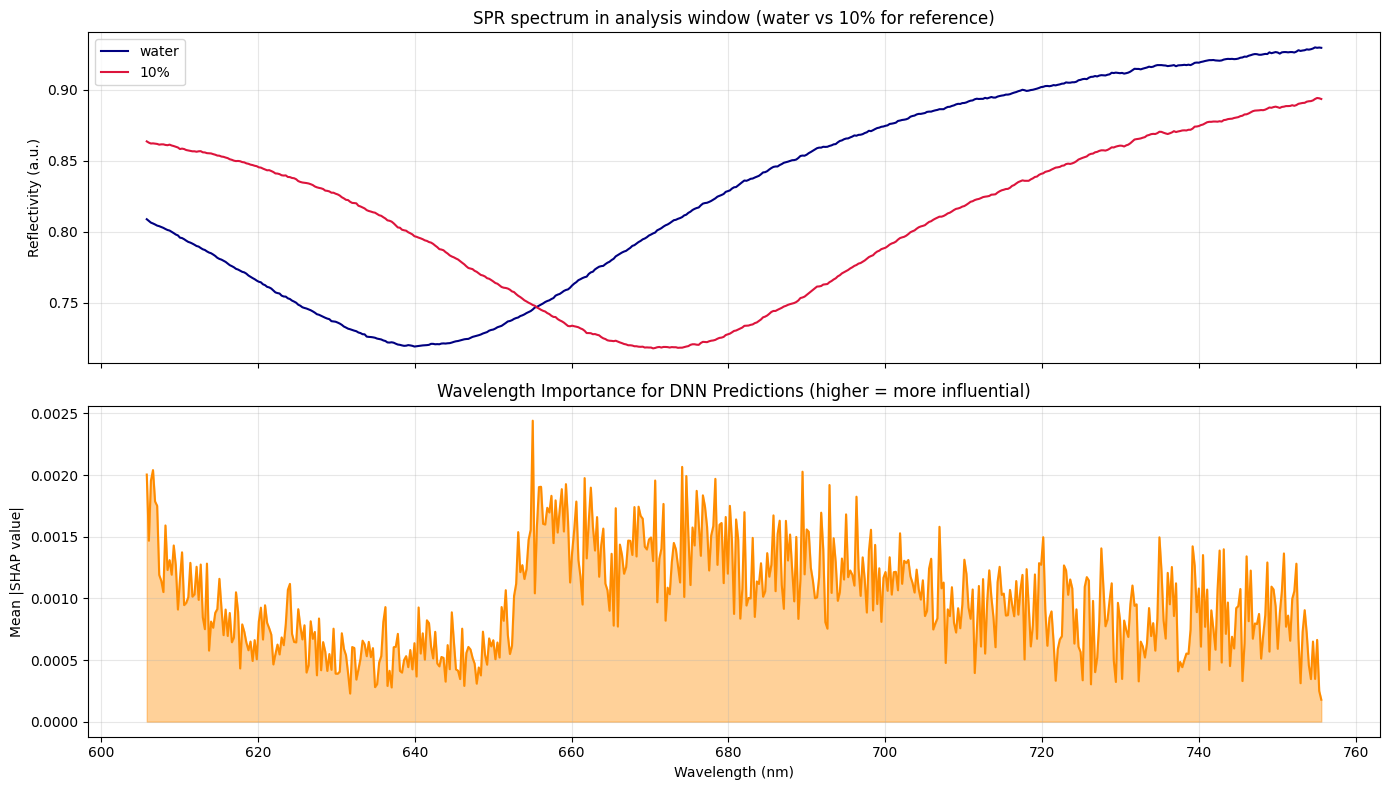


Top 10% most important wavelengths span: 605.8 - 706.9 nm
These account for 17.7% of total model importance

For physical reference, recall from Cell 5:
  Dip wavelength range across concentrations: 640.0 nm (water) to 670.4 nm (10%)
  This is the theoretical region of maximum refractive-index sensitivity (FWHM-adjacent)


In [23]:
# ============================================================
# CELL 23: SHAP Analysis — Which Wavelengths Drive the DNN's Predictions
# ============================================================
!pip install shap -q

import shap

# Background/reference set for SHAP (small random sample of training pairs, scaled)
rng = np.random.RandomState(0)
background_idx = rng.choice(len(X_all_scaled), size=100, replace=False)
background = torch.from_numpy(X_all_scaled[background_idx]).to(device)

# Explain a representative sample of non-zero-label pairs (real exposure responses)
nonzero_mask_all = meta_all["label"].values != 0.0
explain_idx = rng.choice(np.where(nonzero_mask_all)[0], size=200, replace=False)
explain_data = torch.from_numpy(X_all_scaled[explain_idx]).to(device)

final_model.eval()
explainer = shap.DeepExplainer(final_model, background)
shap_values = explainer.shap_values(explain_data)

# shap_values shape: (n_samples, n_features, 1) or (n_samples, n_features) depending on shap version
shap_values = np.array(shap_values).squeeze()
print(f"SHAP values shape: {shap_values.shape}")

mean_abs_shap = np.abs(shap_values).mean(axis=0)  # importance per wavelength point

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# Top: mean spectrum shape in the window, for physical reference
axes[0].plot(window_wavelengths, mean_spectra_by_conc["water"][window_mask], label="water", color='navy')
axes[0].plot(window_wavelengths, mean_spectra_by_conc["10%"][window_mask], label="10%", color='crimson')
axes[0].set_ylabel("Reflectivity (a.u.)")
axes[0].set_title("SPR spectrum in analysis window (water vs 10% for reference)")
axes[0].legend()
axes[0].grid(alpha=0.3)

# Bottom: SHAP importance per wavelength
axes[1].fill_between(window_wavelengths, mean_abs_shap, alpha=0.4, color='darkorange')
axes[1].plot(window_wavelengths, mean_abs_shap, color='darkorange', linewidth=1.5)
axes[1].set_xlabel("Wavelength (nm)")
axes[1].set_ylabel("Mean |SHAP value|")
axes[1].set_title("Wavelength Importance for DNN Predictions (higher = more influential)")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig("/content/shap_wavelength_importance.png", dpi=150)
plt.show()

# --- Quantify: what % of total importance falls in top wavelength segments? ---
sorted_idx = np.argsort(mean_abs_shap)[::-1]
top_10pct_n = max(int(0.1 * len(mean_abs_shap)), 1)
top_wavelengths = window_wavelengths[sorted_idx[:top_10pct_n]]
top_importance_share = mean_abs_shap[sorted_idx[:top_10pct_n]].sum() / mean_abs_shap.sum()

print(f"\nTop 10% most important wavelengths span: {top_wavelengths.min():.1f} - {top_wavelengths.max():.1f} nm")
print(f"These account for {top_importance_share*100:.1f}% of total model importance")
print(f"\nFor physical reference, recall from Cell 5:")
print(f"  Dip wavelength range across concentrations: 640.0 nm (water) to 670.4 nm (10%)")
print(f"  This is the theoretical region of maximum refractive-index sensitivity (FWHM-adjacent)")

np.save("/content/shap_values.npy", shap_values)
np.save("/content/window_wavelengths.npy", window_wavelengths)

In [24]:
# ============================================================
# Quick check: WHERE exactly is SHAP importance concentrated?
# ============================================================
# Find the actual peak location and how importance is distributed,
# in numbers only (no plot needed).

peak_idx = np.argmax(mean_abs_shap)
print(f"Single peak-importance wavelength: {window_wavelengths[peak_idx]:.1f} nm")

# Top 10 individual wavelength points by importance
top10_idx = np.argsort(mean_abs_shap)[::-1][:10]
print("\nTop 10 individual most-important wavelengths (nm) and their SHAP value:")
for idx in sorted(top10_idx):
    print(f"  {window_wavelengths[idx]:.1f} nm -> {mean_abs_shap[idx]:.5f}")

# Importance mass inside vs outside the known dip-shift region (620-680nm from Cell 5)
dip_region_mask = (window_wavelengths >= 620) & (window_wavelengths <= 680)
importance_in_dip_region = mean_abs_shap[dip_region_mask].sum() / mean_abs_shap.sum()
frac_wavelengths_in_dip_region = dip_region_mask.sum() / len(window_wavelengths)

print(f"\nDip-shift region (620-680nm) contains {frac_wavelengths_in_dip_region*100:.1f}% of wavelength points")
print(f"but accounts for {importance_in_dip_region*100:.1f}% of total SHAP importance")

# Split window into 3 equal thirds and compare importance share vs point share
thirds = np.array_split(np.arange(len(window_wavelengths)), 3)
labels = ["low third (605.8-~722)", "mid third", "high third (~739-755.6)"]
for lbl, idxs in zip(labels, thirds):
    share = mean_abs_shap[idxs].sum() / mean_abs_shap.sum()
    print(f"  {lbl}: {share*100:.1f}% of importance ({len(idxs)/len(window_wavelengths)*100:.1f}% of points)")

Single peak-importance wavelength: 655.0 nm

Top 10 individual most-important wavelengths (nm) and their SHAP value:
  605.8 nm -> 0.00200
  606.4 nm -> 0.00195
  606.6 nm -> 0.00204
  655.0 nm -> 0.00244
  661.7 nm -> 0.00198
  670.6 nm -> 0.00196
  674.1 nm -> 0.00207
  674.6 nm -> 0.00199
  678.3 nm -> 0.00197
  689.4 nm -> 0.00203

Dip-shift region (620-680nm) contains 40.0% of wavelength points
but accounts for 40.0% of total SHAP importance
  low third (605.8-~722): 25.9% of importance (33.3% of points)
  mid third: 45.3% of importance (33.3% of points)
  high third (~739-755.6): 28.7% of importance (33.3% of points)


## Summary of Findings

- The DNN-based sensor response achieved an **8–10× higher SNR** than classical
  dip-position and centroid-position tracking at equilibrium (t = 60s), across
  all non-zero sucrose concentrations.
- **Leave-One-Repetition-Out cross-validation** (Cells 18–19) revealed genuine
  session-to-session variability in model generalization (MAE 0.03–0.26 across
  the 10 folds), traced to real differences in sensor responsiveness between
  recording sessions — not resolved by class rebalancing or intensity
  normalization (Cells 13–17). This is a documented limitation, not an
  unexplained failure.
- **SHAP analysis** (Cells 23–24) showed model importance distributed across
  the analysis window rather than sharply concentrated at the SPR dip,
  suggesting the model may rely more on the resonance curve's flanks (slope
  regions) than the dip minimum itself — a finding that diverges from the
  reference study and merits further investigation.
- All training was performed on a single Colab free-tier **NVIDIA T4 GPU**,
  confirming that this problem scale does not require expensive compute
  infrastructure.

Full discussion, figures, and the complete written report are provided separately.